In [9]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

DATA_DIR    = Path("../../data/processed")
MATRIX_PATH = DATA_DIR / "feature_matrix.parquet"

fm = pd.read_parquet(MATRIX_PATH)

print(f"Feature matrix: {fm.shape[0]} orgs, {fm.shape[1]} columns")
fm.head(3)

Feature matrix: 344 orgs, 11 columns


,ein,org_name,org_state,org_ntee_code,tax_prd_yr,program_expense_ratio,admin_overhead_ratio,net_asset_margin,labor_cost_ratio,solvency_ratio,revenue_yoy_growth
0,042632526,Elderhostel Inc,MA,N500,2024,1.013286,-0.932392,-0.542861,-0.951506,-0.537092,-0.269264
1,042775991,Metropolitan Boston Housing Partnership Inc,MA,L20,2024,0.866517,-0.800522,-0.672369,-1.268384,-0.553633,0.430018
2,341747398,American Endowment Foundation,OH,T31,2023,-1.457823,1.398050,2.181113,-1.426526,2.923457,-0.041517


Isolate Feature Columns

In [10]:
META_COLS = ["ein", "org_name", "org_state", "org_ntee_code", "tax_prd_yr"]
FEATURE_COLS = [c for c in fm.columns if c not in META_COLS]

print(f"Feature columns ({len(FEATURE_COLS)}):")
for col in FEATURE_COLS:
    print(f"  {col}")

X = fm[FEATURE_COLS].values.astype(np.float32)
print(f"\nX shape: {X.shape}")

Feature columns (6):
  program_expense_ratio
  admin_overhead_ratio
  net_asset_margin
  labor_cost_ratio
  solvency_ratio
  revenue_yoy_growth

X shape: (344, 6)


Synthesize the `y` Label
- Weighted formula encoding Atlas990's definition of a high-value lead.
- Each component is already normalized (StandardScaler from transformer) so the weights are directly comparable.

| Feature | Weight | Rationale |
|---|---|---|
| program_expense_ratio | 0.30 | Mission-focused, well-run org |
| revenue_yoy_growth | 0.25 | Growing = expanding budget = better timing |
| solvency_ratio | 0.20 | Financially stable = can actually buy |
| net_asset_margin | 0.15 | Has reserves = not cash-strapped |
| admin_overhead_ratio | -0.10 | Inverted: high overhead is a negative signal |

In [11]:
# Map feature names to their column index in X
col_idx = {col: i for i, col in enumerate(FEATURE_COLS)}

# Weighted sum — note admin_overhead_ratio is negative (inverted signal)
raw_score = (
    0.30 * X[:, col_idx["program_expense_ratio"]] +
    0.25 * X[:, col_idx["revenue_yoy_growth"]]    +
    0.20 * X[:, col_idx["solvency_ratio"]]         +
    0.15 * X[:, col_idx["net_asset_margin"]]        +
   -0.10 * X[:, col_idx["admin_overhead_ratio"]]   # high overhead = bad signal
)

# Normalize to 0–100
score_min = raw_score.min()
score_max = raw_score.max()
y = ((raw_score - score_min) / (score_max - score_min) * 100).astype(np.float32)

print(f"y distribution:")
print(f"  min:    {y.min():.2f}")
print(f"  max:    {y.max():.2f}")
print(f"  mean:   {y.mean():.2f}")
print(f"  median: {np.median(y):.2f}")
print(f"  std:    {y.std():.2f}")

y distribution:
  min:    0.00
  max:    100.00
  mean:   42.32
  median: 45.19
  std:    15.38


Score Distribution Visualization

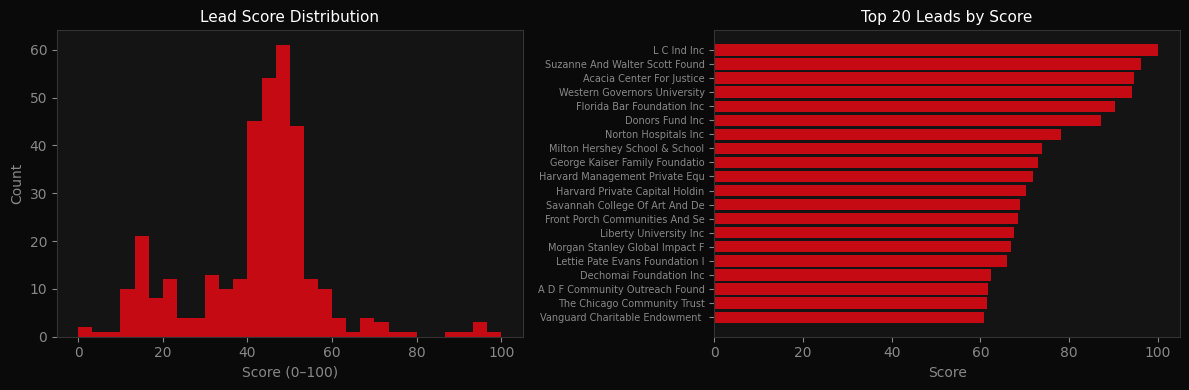

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0a0a0a')

# Histogram
axes[0].set_facecolor('#141414')
axes[0].hist(y, bins=30, color='#E50914', alpha=0.85, edgecolor='none')
axes[0].set_title('Lead Score Distribution', color='white', fontsize=11)
axes[0].set_xlabel('Score (0–100)', color='#888888')
axes[0].set_ylabel('Count', color='#888888')
axes[0].tick_params(colors='#888888')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#333333')

# Top 20 orgs by score
top20_idx = np.argsort(y)[::-1][:20]
top20_names = fm["org_name"].iloc[top20_idx].str[:30].values
top20_scores = y[top20_idx]

axes[1].set_facecolor('#141414')
bars = axes[1].barh(range(20), top20_scores[::-1], color='#E50914', alpha=0.85)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top20_names[::-1], color='#888888', fontsize=7)
axes[1].set_title('Top 20 Leads by Score', color='white', fontsize=11)
axes[1].set_xlabel('Score', color='#888888')
axes[1].tick_params(colors='#888888')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333333')

plt.tight_layout()
plt.show()

Train / Test Split

In [13]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, fm.index.values,
    test_size=0.20,
    random_state=42
)

print(f"Train: {X_train.shape[0]} orgs")
print(f"Test:  {X_test.shape[0]} orgs")

Train: 275 orgs
Test:  69 orgs


In [14]:
# Load Model and Fit
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,       # L1 regularization
    reg_lambda=1.0,      # L2 regularization
    eval_metric="mae",
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print(f"Training complete")
print(f"Best iteration: {model.best_iteration}")

Training complete
Best iteration: 199


Evaluate on Test Set

In [15]:
y_pred = model.predict(X_test)

# Clamp predictions to 0–100
y_pred = np.clip(y_pred, 0, 100)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Test MAE:  {mae:.2f} score points")
print(f"Test R²:   {r2:.4f}")
print()

# Sample predictions vs actuals
comparison = pd.DataFrame({
    "org_name":  fm["org_name"].iloc[idx_test].values,
    "actual":    y_test.round(1),
    "predicted": y_pred.round(1),
    "delta":     (y_pred - y_test).round(1),
}).sort_values("actual", ascending=False).reset_index(drop=True)

print("Sample predictions (top 15 by actual score):")
comparison.head(15)

Test MAE:  2.45 score points
Test R²:   0.9471

Sample predictions (top 15 by actual score):


,org_name,actual,predicted,delta
0,L C Ind Inc,100.000000,83.500000,-16.5
1,Milton Hershey School & School Trust,74.000000,63.200001,-10.8
2,Front Porch Communities And Services,68.500000,62.299999,-6.3
3,Morgan Stanley Global Impact Funding Trust Inc,67.000000,63.599998,-3.3
4,Lettie Pate Evans Foundation Inc Trustee Of Th...,66.000000,69.400002,3.4
5,A D F Community Outreach Foundation Inc,61.599998,52.700001,-9.0
6,Sentara Hospitals,57.099998,59.299999,2.1
7,Loyola University Of Chicago,55.000000,54.700001,-0.3
8,Vanderbilt University,53.299999,50.000000,-3.3
9,Father Flanagans Boys Home,52.099998,50.799999,-1.3


Feature Importance Analytics

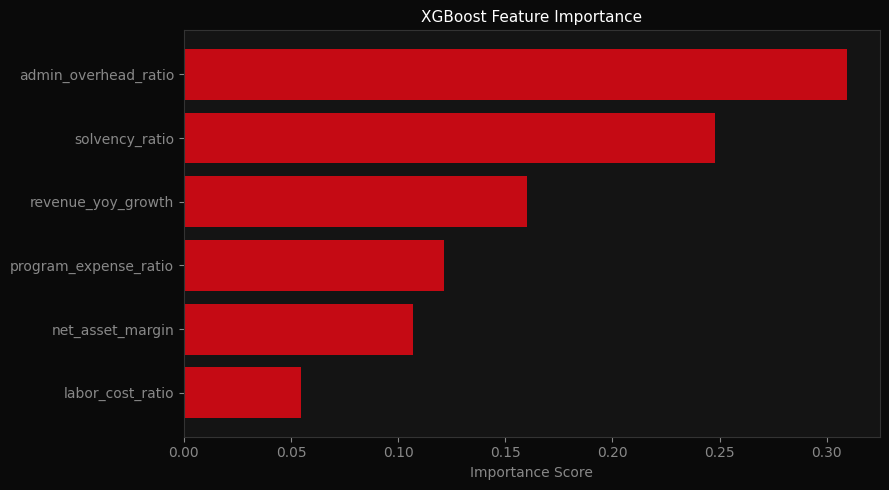

admin_overhead_ratio     0.309361
solvency_ratio           0.247719
revenue_yoy_growth       0.160111
program_expense_ratio    0.121314
net_asset_margin         0.106700
labor_cost_ratio         0.054796


In [16]:
importance = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#141414')

ax.barh(importance.index, importance.values, color='#E50914', alpha=0.85)
ax.set_title('XGBoost Feature Importance', color='white', fontsize=11)
ax.set_xlabel('Importance Score', color='#888888')
ax.tick_params(colors='#888888')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).to_string())

Run the model on the whole

In [17]:
all_scores = model.predict(X)
all_scores = np.clip(all_scores, 0, 100).round(1)

scored = fm[["ein", "org_name", "org_state", "org_ntee_code", "tax_prd_yr"]].copy()
scored["lead_score"] = all_scores
scored = scored.sort_values("lead_score", ascending=False).reset_index(drop=True)

print("Top 20 leads:")
scored.head(20)

Top 20 leads:


,ein,org_name,org_state,org_ntee_code,tax_prd_yr,lead_score
0,363727897,Suzanne And Walter Scott Foundation,NE,T900,2023,96.000000
1,874099467,Acacia Center For Justice,NY,P84,2023,94.000000
2,474365018,Western Governors University,UT,B03,2023,92.900002
3,591004604,Florida Bar Foundation Inc,FL,I120,2023,89.800003
4,474844275,Donors Fund Inc,NJ,T30,2023,86.599998
5,560686307,L C Ind Inc,NC,P860,2023,83.500000
6,610703799,Norton Hospitals Inc,KY,E220,2023,77.000000
7,731574370,George Kaiser Family Foundation,OK,T110,2023,73.300003
8,043070522,Harvard Management Private Equity Corporation,MA,B110,2023,70.500000
9,043070519,Harvard Private Capital Holdings Inc,MA,B020,2017,69.699997


Save Scored Dataset

In [18]:
import pickle

MODELS_DIR  = Path("../../data/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save the trained model
MODEL_PATH = MODELS_DIR / "xgboost_scorer.pkl"
with open(MODEL_PATH, "wb") as f:
    pickle.dump(model, f)

# Save score normalization params so inference stays consistent
NORM_PATH = MODELS_DIR / "score_norm.pkl"
with open(NORM_PATH, "wb") as f:
    pickle.dump({"min": float(score_min), "max": float(score_max)}, f)

# Save scored org list
SCORED_PATH = DATA_DIR / "scored_orgs.parquet"
scored.to_parquet(SCORED_PATH, index=False, engine="pyarrow")

print(f"Model saved       → {MODEL_PATH.resolve()}")
print(f"Norm params saved → {NORM_PATH.resolve()}")
print(f"Scored orgs saved → {SCORED_PATH.resolve()}")
print(f"\nTotal orgs scored: {len(scored)}")
print(f"Score range: {scored['lead_score'].min()} – {scored['lead_score'].max()}")

Model saved       → C:\Users\Edrill-LT\Documents\Projects\Atlas990\backend\data\models\xgboost_scorer.pkl
Norm params saved → C:\Users\Edrill-LT\Documents\Projects\Atlas990\backend\data\models\score_norm.pkl
Scored orgs saved → C:\Users\Edrill-LT\Documents\Projects\Atlas990\backend\data\processed\scored_orgs.parquet

Total orgs scored: 344
Score range: 3.700000047683716 – 96.0
